# EDA(Exploratory Data Analysis, 탐색적 데이터 분석)

그래프 시각화나 통계적인 방법으로 자료를 분석하는 과정.

# 필요한 모듈 임포트

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# iris 데이터셋

*   seaborn 모듈의 iris 데이터셋을 로드 -> DataFrame
*   iris 데이터프레임의 확인 - 요약, 기술통계량, 카테고리 타입 빈도수
*   숫자 타입 변수들의 box plot
*   숫자 타입 변수들의 평균 막대 그래프
*   품종별 모든 연속형 변수들의 box plot
*   품종별 모든 연속형 변수들의 평균 막대 그래프
*   petal_length ~ petal_width 산점도, 품종별로 색깔을 다르게 시각화.
*   모든 연속형 변수들 간의 상관관계(산점도). 힌트: `pairplot()`

In [2]:
iris = sns.load_dataset("iris")

iris.head()  # tail()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [60]:
iris.sepal_length.describe()

,sepal_length
count,150.000000
mean,5.843333
std,0.828066
min,4.300000
25%,5.100000
50%,5.800000
75%,6.400000
max,7.900000


In [6]:
iris.species.value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


## 숫자 타입 변수들의 box plot

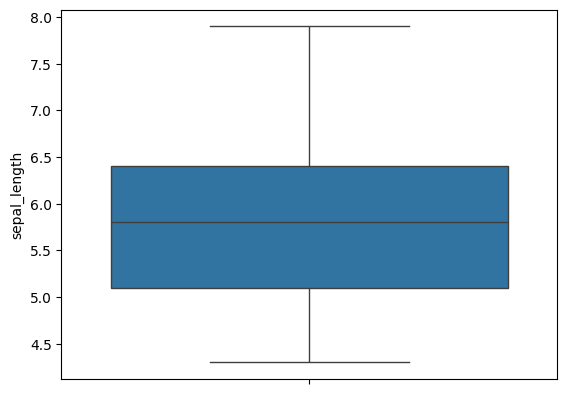

In [61]:
# 강사님 답안
sns.boxplot(data=iris, y="sepal_length")
plt.show()

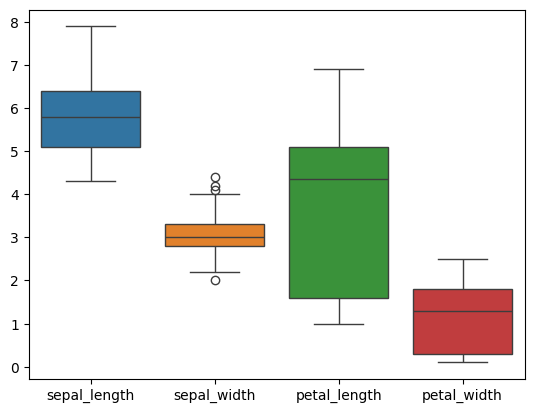

In [62]:
# 강사님 답안
sns.boxplot(data=iris)
plt.show()

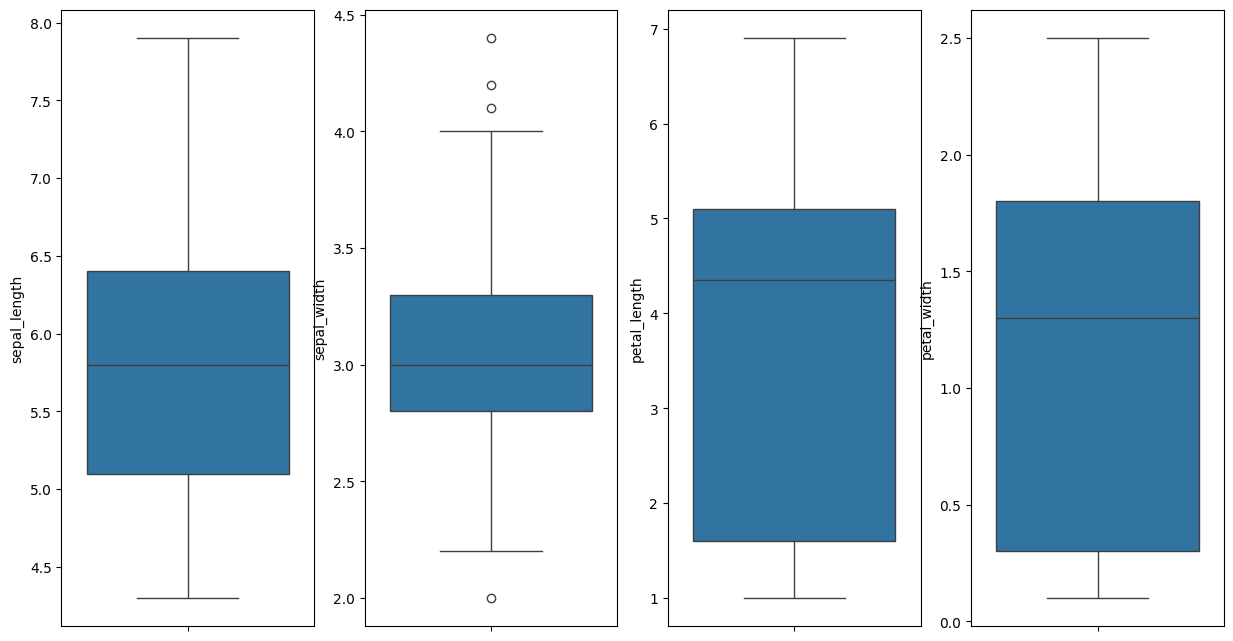

In [34]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(15, 8))

sns.boxplot(data=iris, y="sepal_length", ax=axes[0])
sns.boxplot(data=iris, y="sepal_width", ax=axes[1])
sns.boxplot(data=iris, y="petal_length", ax=axes[2])
sns.boxplot(data=iris, y="petal_width", ax=axes[3])

plt.show()

## 숫자 타입 변수들의 평균 막대 그래프

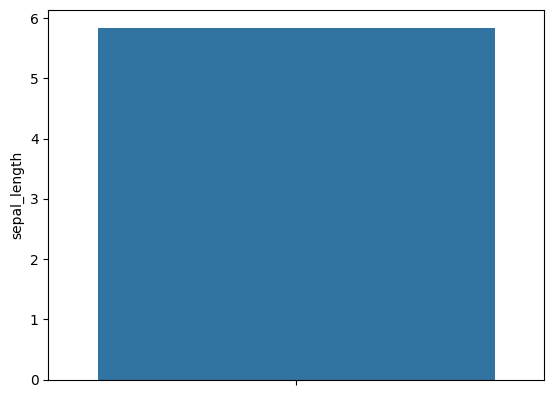

In [63]:
# 강사님 답안
sns.barplot(data=iris, y="sepal_length", errorbar=None)

plt.show()

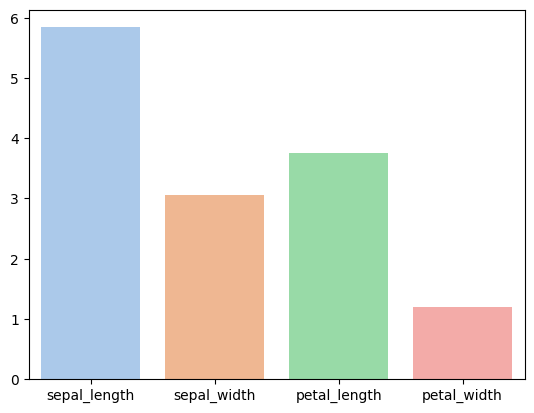

In [65]:
# 강사님 답안
sns.barplot(data=iris, errorbar=None, palette="pastel")
plt.show()

In [71]:
# 강사님 답안
iris.sepal_length.mean()

iris[["sepal_length", "sepal_width"]].mean()

iris.columns[0]  # 배열 indexing
iris.columns[:4]  # 배열 slicing

iris[iris.columns[:-1]].mean()

,0
sepal_length,5.843333
sepal_width,3.057333
petal_length,3.758000
petal_width,1.199333


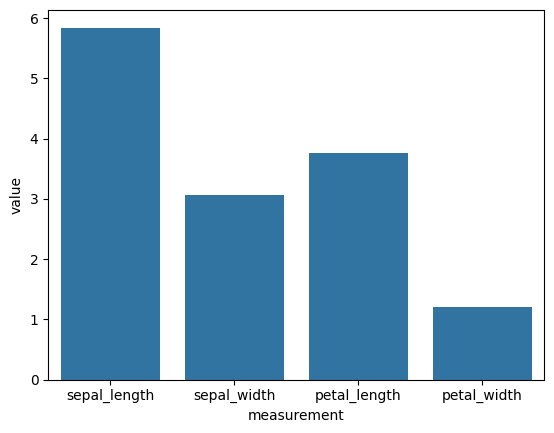

In [41]:
# melt 실행
# id_vars='species' : 이 컬럼은 고정하고 나머지를 쌓아라
iris_melted = iris.melt(id_vars='species', var_name='measurement', value_name='value')

sns.barplot(data=iris_melted, y="value", x="measurement", errorbar=None)

plt.show()

## 품종별 box plot

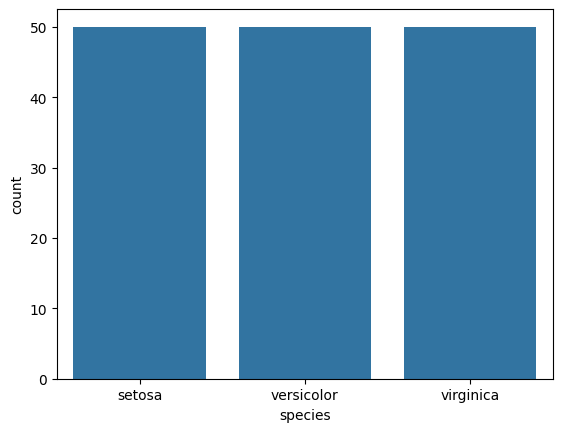

In [72]:
# 강사님 답안
sns.countplot(data=iris, x="species")
plt.show()

In [74]:
# 강사님 답안
iris[iris.species == "setosa"].describe()

,sepal_length,sepal_width,petal_length,petal_width
count,50.00000,50.000000,50.000000,50.000000
mean,5.00600,3.428000,1.462000,0.246000
std,0.35249,0.379064,0.173664,0.105386
min,4.30000,2.300000,1.000000,0.100000
25%,4.80000,3.200000,1.400000,0.200000
50%,5.00000,3.400000,1.500000,0.200000
75%,5.20000,3.675000,1.575000,0.300000
max,5.80000,4.400000,1.900000,0.600000


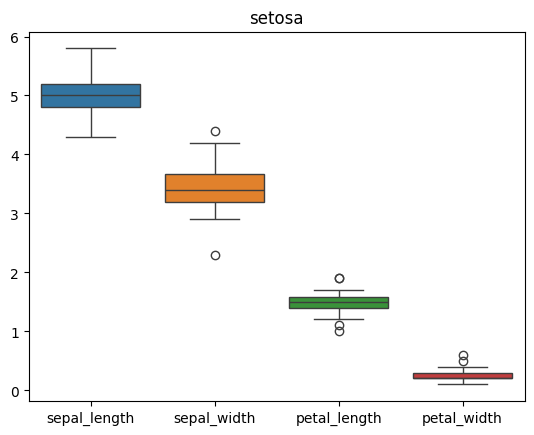

In [76]:
# 강사님 답안
setosa = iris[iris.species == "setosa"]
sns.boxplot(data=setosa)

plt.title("setosa")
plt.show()

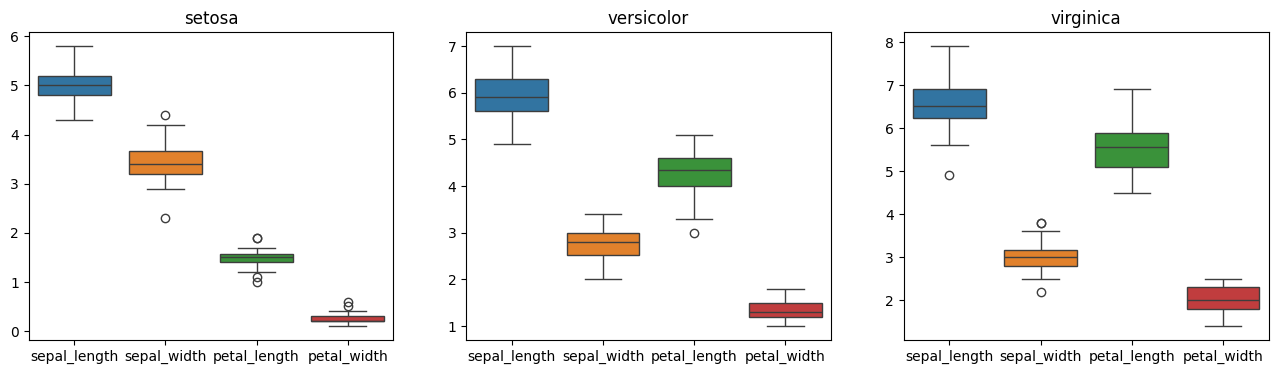

In [84]:
# 강사님 답안
species = iris.species.unique()
# print(species)
# print(len(species))

fig, axes = plt.subplots(ncols=len(species), figsize=(16, 4))

for i, s in enumerate(species):
    # print(i, s)
    subset_df = iris[iris.species == s]
    sns.boxplot(data=subset_df, ax=axes[i])
    axes[i].set_title(s)

plt.show()

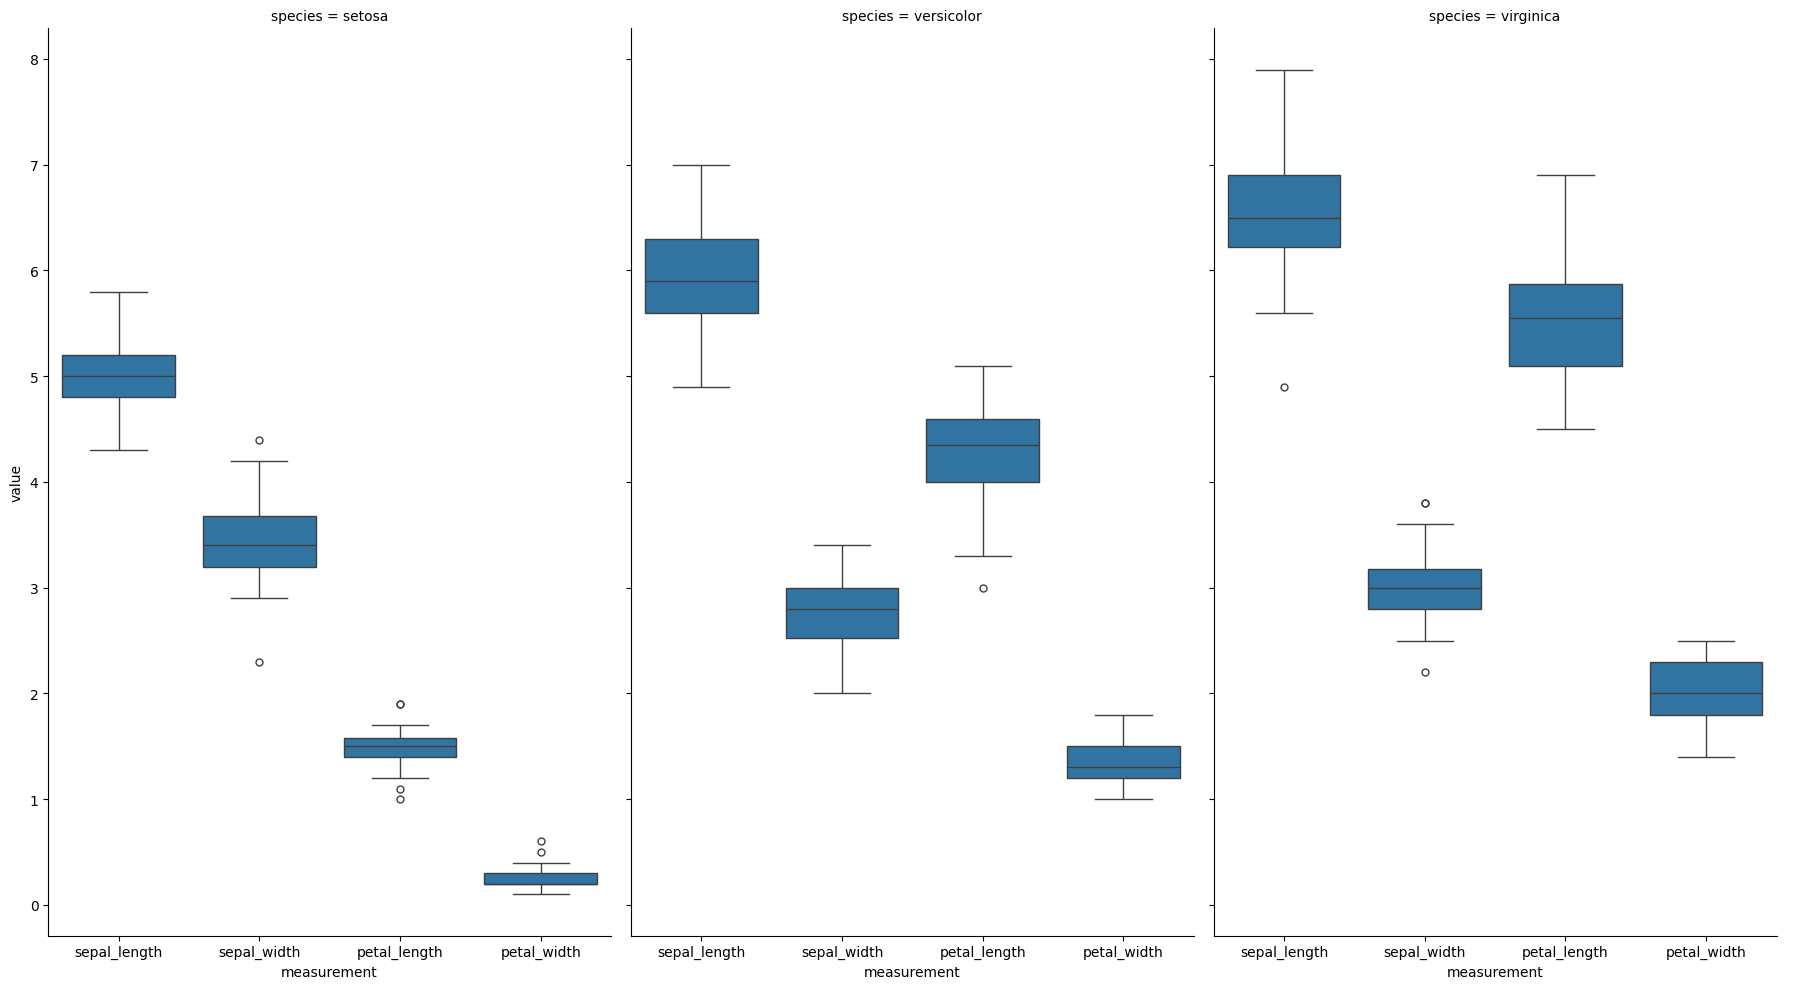

In [54]:
sns.catplot(data=iris_melted, x="measurement", y="value", kind="box", col="species", height=10, aspect=0.6)

plt.show()

## 품종별 막대 그래프

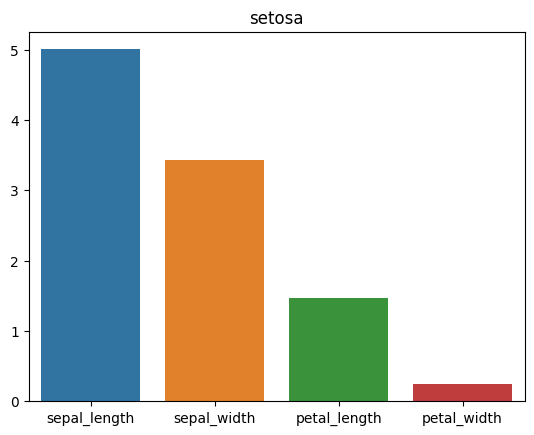

In [86]:
# 강사님 답안
setosa = iris[iris.species == "setosa"]
sns.barplot(data=setosa, errorbar=None)

plt.title("setosa")
plt.show()

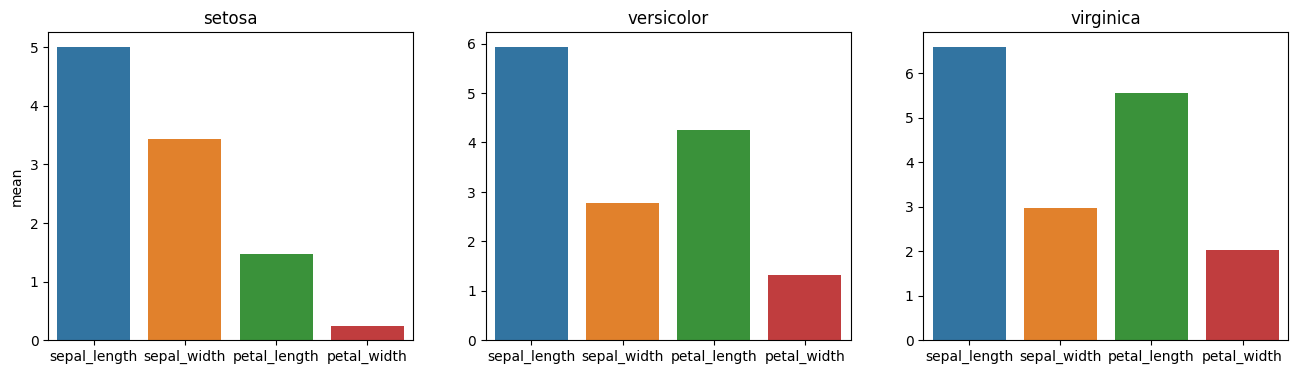

In [90]:
# 강사님 답안
fig, axes = plt.subplots(ncols=len(species), figsize=(16, 4))

for i, s in enumerate(species):
    subset_df = iris[iris.species == s]
    sns.barplot(data=subset_df, ax=axes[i], errorbar=None)
    axes[i].set_title(s)
    # axes[i].set_ylabel("mean")

axes[0].set_ylabel("mean")
plt.show()

In [93]:
# 강사님 답안
iris.groupby(by=["species"]).sepal_length.mean()

iris.groupby(by=["species"])[["sepal_length", "sepal_width"]].mean()

iris.groupby(by=["species"])[iris.columns[:-1]].mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


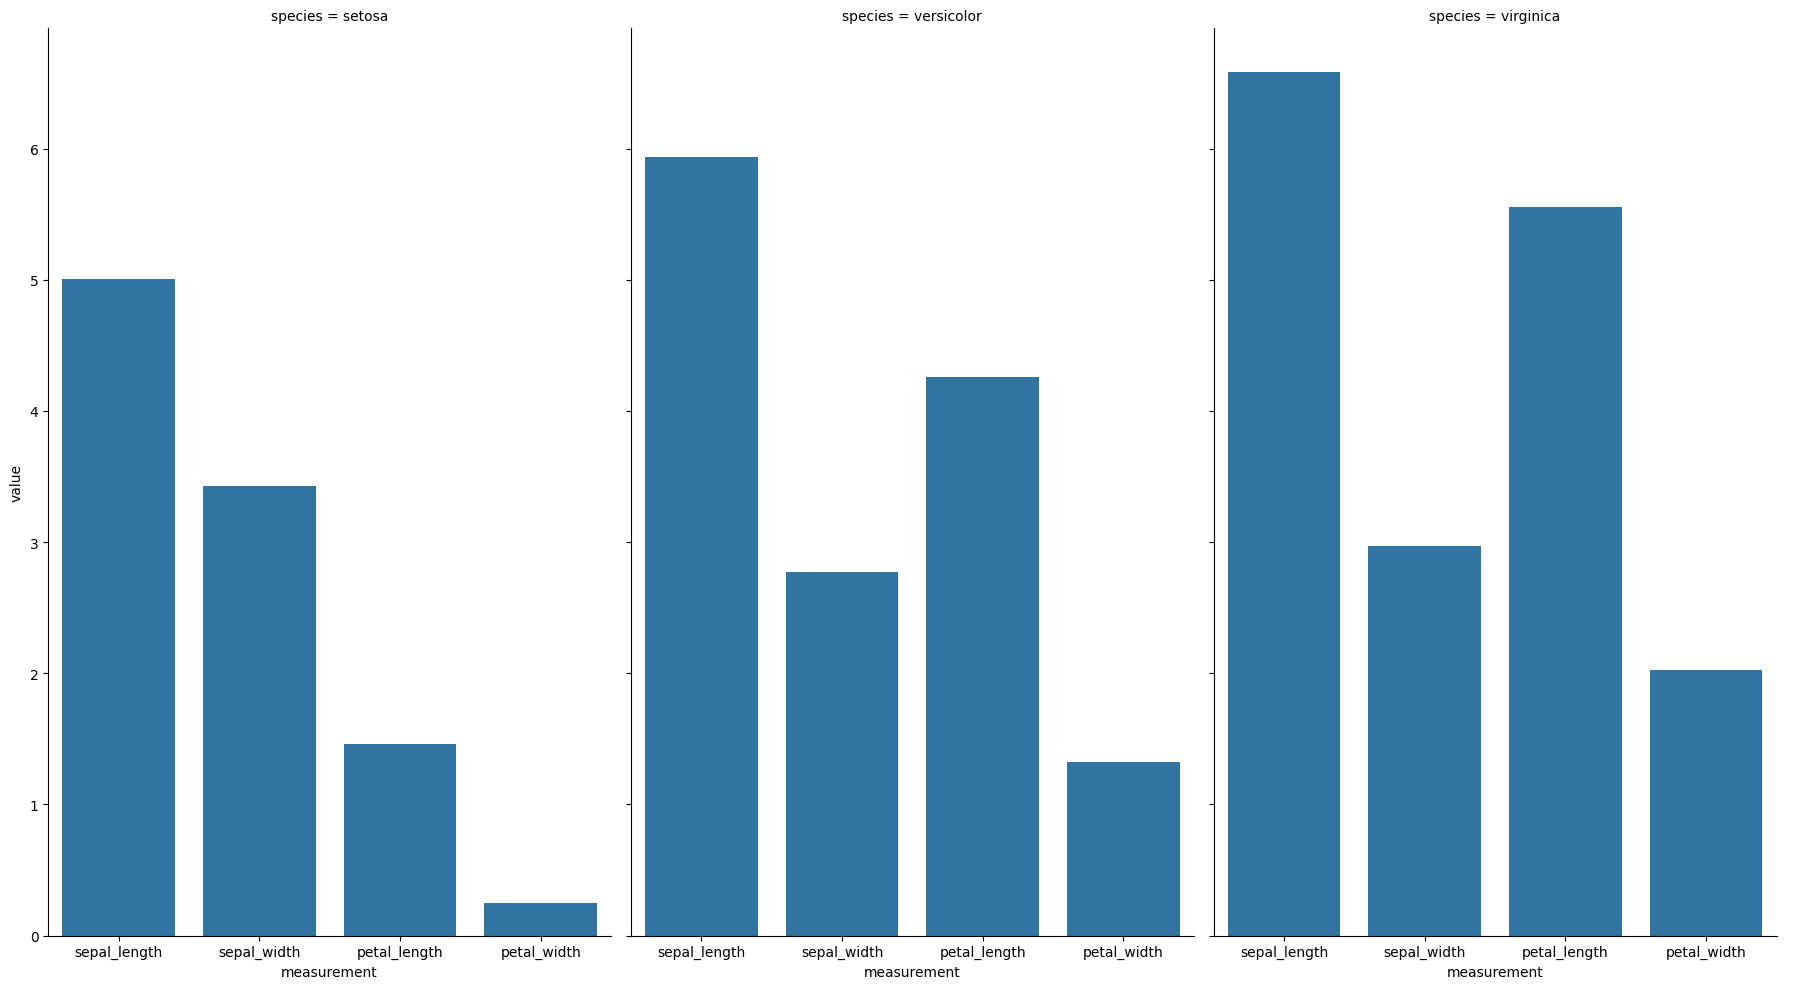

In [57]:
sns.catplot(data=iris_melted, x="measurement", y="value", kind="bar", col="species", height=10, aspect=0.6, errorbar=None)

plt.show()

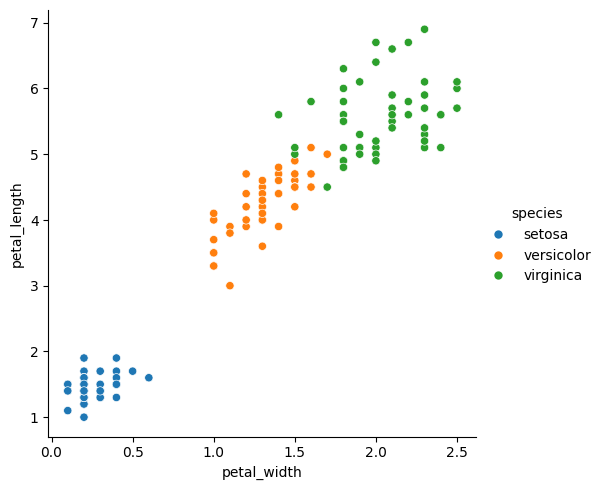

In [58]:
sns.relplot(data=iris, x="petal_width", y="petal_length", hue="species")

plt.show()

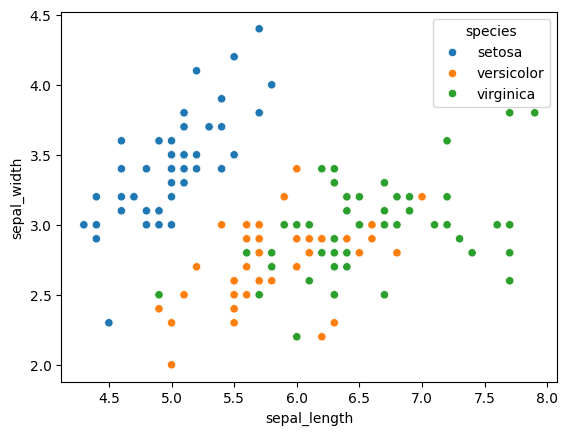

In [94]:
sns.scatterplot(data=iris, x="sepal_length", y="sepal_width", hue="species")

plt.show()

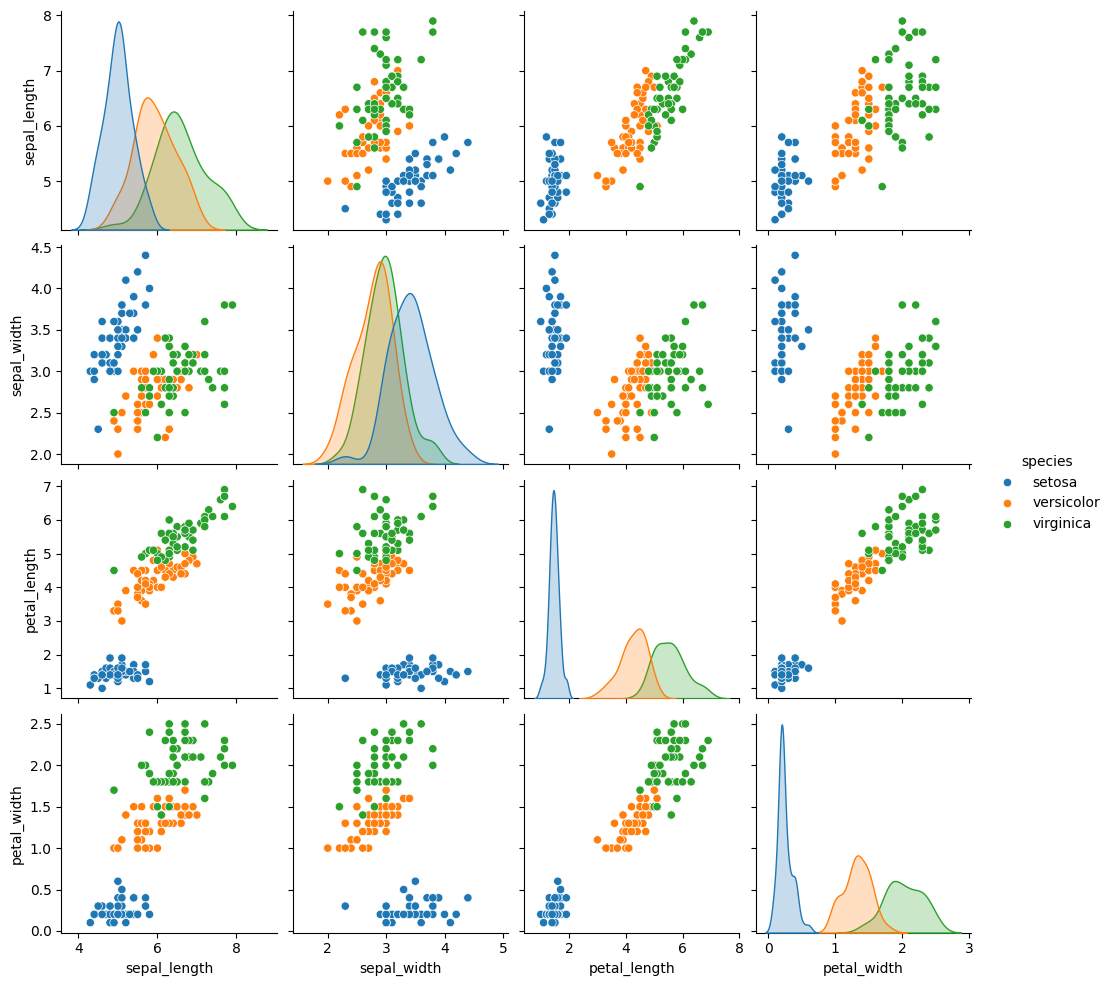

In [95]:
sns.pairplot(data=iris, hue="species")

plt.show()

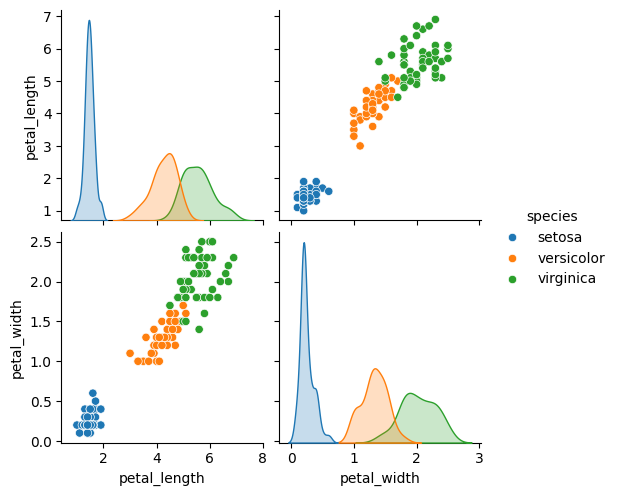

In [96]:
sns.pairplot(data=iris[["petal_length", "petal_width", "species"]], hue="species")

plt.show()

# mpg

*   seaborn 패키지의 예제 데이터 셋 'mpg'를 로드해서 DataFrame 생성
*   DataFrame 확인 - 출력, 요약 정보, 숫자 타입 기술 통계량, 카테고리 타입 빈도수

*   산점도
    *   mpg(연비) ~ displacement(배기량)
    *   2x2 모양의 subplot을 생성
        *   mpg ~ cylinders(실린더 개수)
        *   mpg ~ horsepower(마력)
        *   mpg ~ weight(무게)
        *   mpg ~ acceleration(가속도)

*   빈도수 막대 그래프
    *   cyliners 빈도수
    *   origin(자동차 생산 지역)빈도수
    *   model_year(자동차 생산 연도)빈도수
        *   선 그래프 가능?
    *   origin 별, cylinders 별 빈도수

*   통계량 막대 그래프 - 2개의 subplot 생성

    *   cylinders 별 mpg의 중앙값(median)
    *   origin 별 mpg의 중앙값

*   Box plot

    *   3개의 subplot을 생성
        *   mpg, displacement, weight box plot
    *   origin 별 mpg box plot

*   Histogram

    *   4개의 subplot을 생성
        *   mpg, displacement, weight, model_year histogram

*   Pair plot

In [97]:
mpg = sns.load_dataset(name="mpg")

mpg 데이터프레임의 컬럼:

    *   mpg: Mile per Gallon. 자동차 연비.
    *   cylinders: 자동차 실린더 개수.
    *   displacement: 배기량.
    *   horsepower: 마력.
    *   weight: 무게.
    *   acceleration: 가속도.
    *   model_year: 자동차 모델 연도.
    *   origin: 자동차 생산 지역.
    *   name: 자동차 이름.

In [98]:
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [99]:
mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [106]:
mpg[mpg["horsepower"].isnull()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
32,25.0,4,98.0,NaN,2046,19.0,71,usa,ford pinto
126,21.0,6,200.0,NaN,2875,17.0,74,usa,ford maverick
330,40.9,4,85.0,NaN,1835,17.3,80,europe,renault lecar deluxe
336,23.6,4,140.0,NaN,2905,14.3,80,usa,ford mustang cobra
354,34.5,4,100.0,NaN,2320,15.8,81,europe,renault 18i
374,23.0,4,151.0,NaN,3035,20.5,82,usa,amc concord dl
